In [1]:
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.append("..")

from src.utils import *

In [6]:
import ipyparallel as ipp

# Connect to the running default cluster
rc = ipp.Client()
print(f"Connected to {len(rc.ids)} engines.")

Connected to 8 engines.


In [7]:
%%px
import os
import numpy as np
print(f"Hello from process ID: {os.getpid()}")

[stdout:5] Hello from process ID: 1427039


[stdout:6] Hello from process ID: 1427044


[stdout:7] Hello from process ID: 1427053


[stdout:3] Hello from process ID: 1427026


[stdout:4] Hello from process ID: 1427031


[stdout:0] Hello from process ID: 1427016


[stdout:2] Hello from process ID: 1427021


[stdout:1] Hello from process ID: 1427019


## 

The goal of this research project is to be able to extract the dyamical critical exponent from a multi-species exclusion process using just Topological Data Analysis. Note that 

In [2]:
def h0_persistence_1d(x):
    """
    H0 persistence for a one-dimensional point cloud.

    For points on a line, finite H0 death times are the gaps between
    neighboring sorted points. Large death times mean large gaps / separated
    clusters. Small death times mean dense / tightly packed points.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 2:
        return {
            "h0_max_persistence": np.nan,
            "h0_total_persistence": np.nan,
            "h0_mean_persistence": np.nan,
            "h0_num_components": len(x),
        }

    x_sorted = np.sort(x)
    gaps = np.diff(x_sorted)

    return {
        "h0_max_persistence": np.max(gaps),
        "h0_total_persistence": np.sum(gaps),
        "h0_mean_persistence": np.mean(gaps),
        "h0_num_components": len(x),
    }

In [3]:
L_values = np.arange(30, 300, 3)
rates_matrix = np.triu(np.ones((3, 3), dtype=np.float64), k=1)

taus = []
h0_max_values = []
h0_total_values = []
h0_mean_values = []

for L in L_values:
    
    process = MultiSpeciesExclusionProcess(
        dimension=3,
        density=[1/3, 1/3, 1/3],
        rates_matrix=rates_matrix,
        length=L
    )
    
    X = process.fourier_time_series(n_samples=30000, mode=1)

    # Usual dynamical critical exponent calculation
    C = autocorrelation(X[:, 0])
    taus.append(relaxation_time(C))

    # H0 persistence of the sampled Fourier-mode point cloud
    h0_stats = h0_persistence_1d(X[:, 0])

    h0_max_values.append(h0_stats["h0_max_persistence"])
    h0_total_values.append(h0_stats["h0_total_persistence"])
    h0_mean_values.append(h0_stats["h0_mean_persistence"])

taus = np.array(taus)
h0_max_values = np.array(h0_max_values)
h0_total_values = np.array(h0_total_values)
h0_mean_values = np.array(h0_mean_values)

/home/dupreti/TDA-Diffusion-Models/.venv/lib64/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


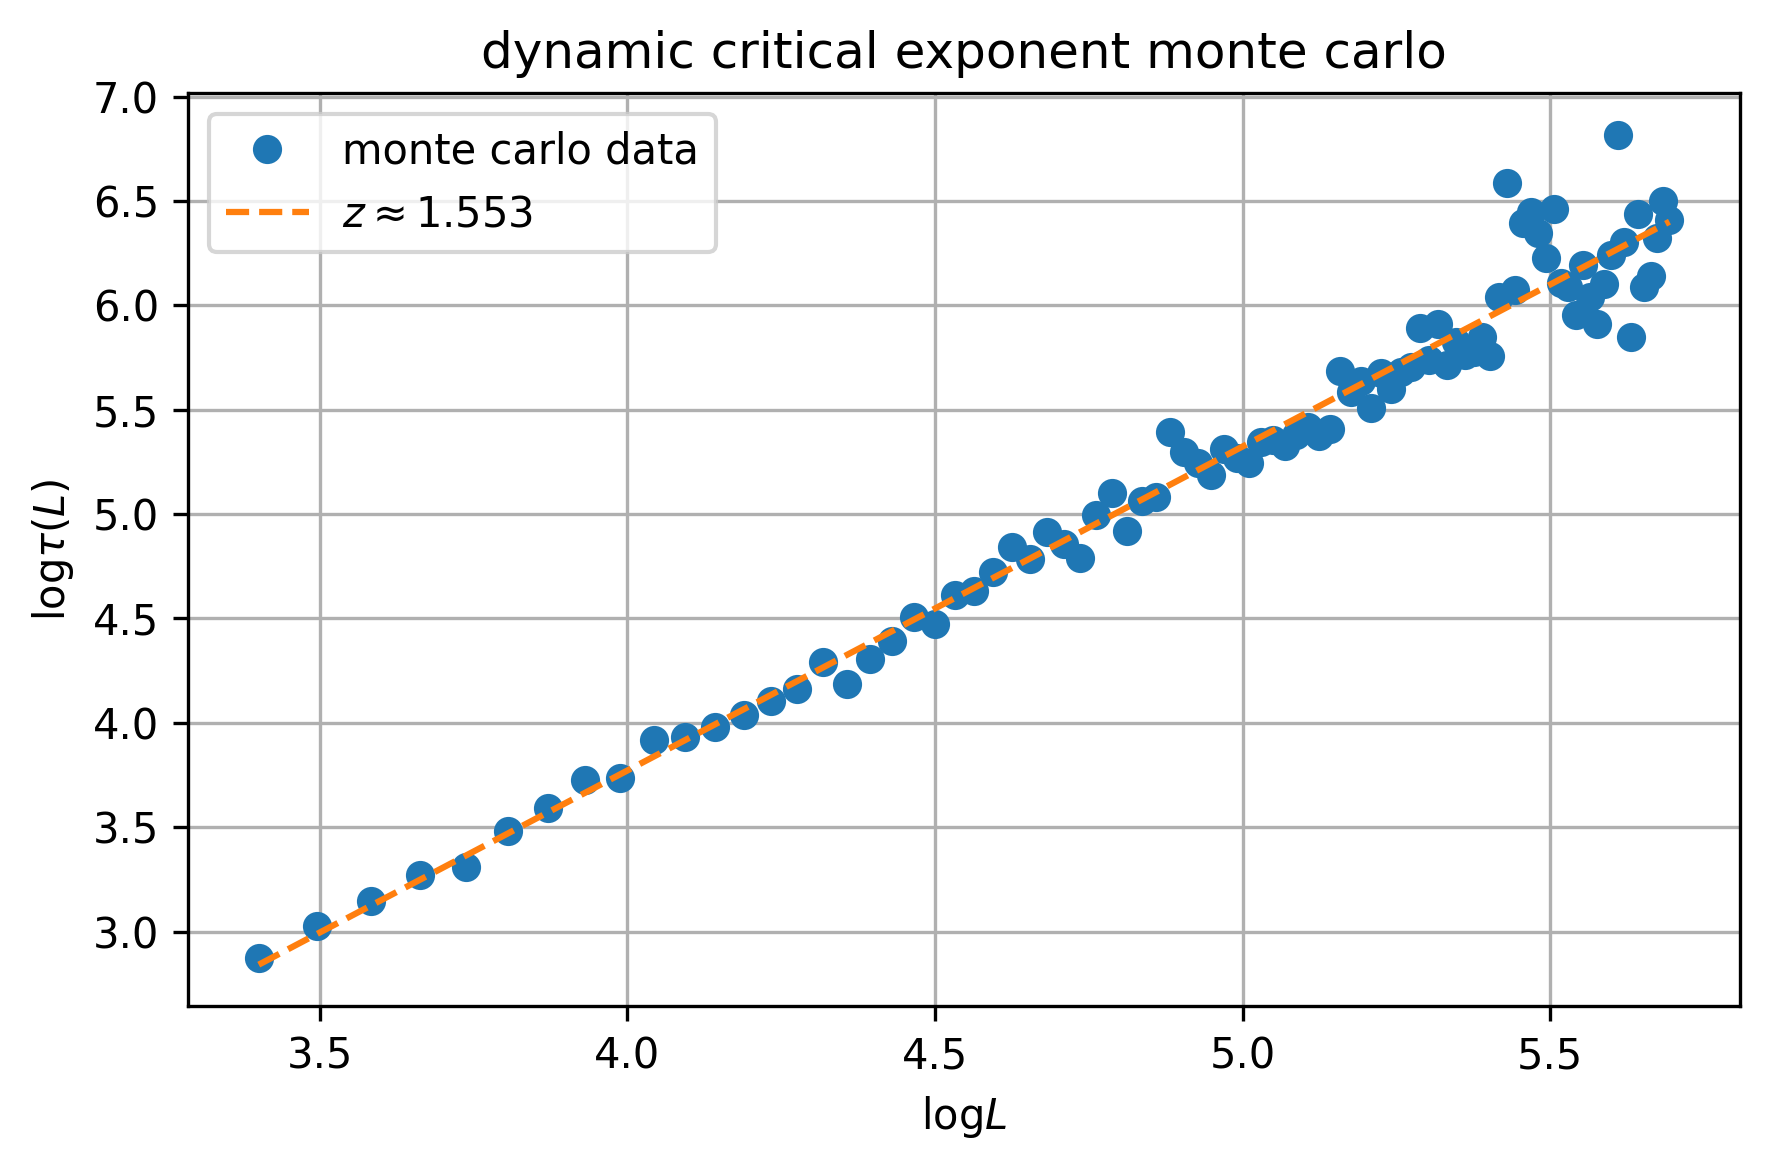

In [4]:
valid = np.isfinite(taus) & (taus > 0)

logL = np.log(L_values[valid])
logtau = np.log(taus[valid])      

z, intercept = np.polyfit(logL, logtau, 1)
fit = intercept + z * logL

plt.figure(figsize=(6, 4), dpi=300)
plt.plot(logL, logtau, "o", label="monte carlo data")
plt.plot(logL, fit, "--", label=fr"$z \approx {z:.3f}$")

plt.xlabel(r"$\log L$")
plt.ylabel(r"$\log \tau(L)$")
plt.title(r"dynamic critical exponent monte carlo")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

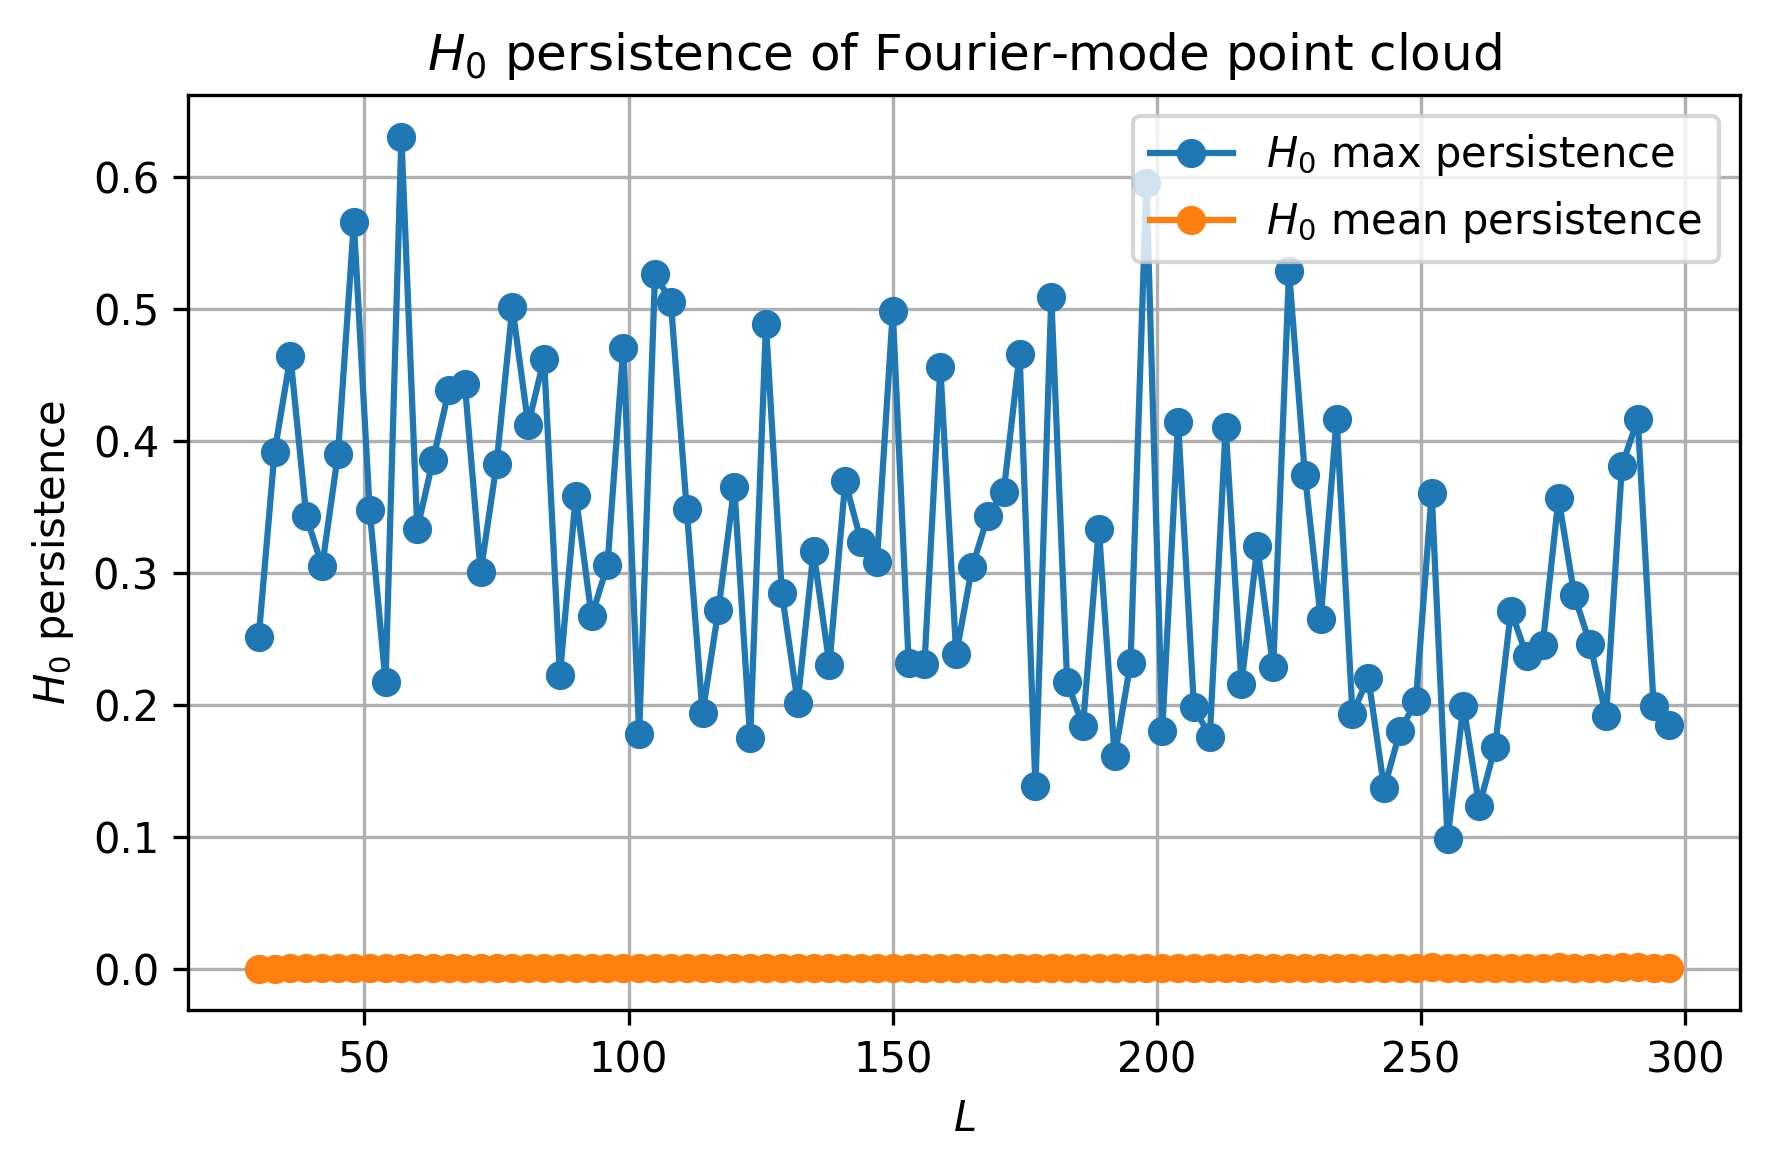

In [5]:
plt.figure(figsize=(6, 4), dpi=300)
plt.plot(L_values, h0_max_values, "o-", label=r"$H_0$ max persistence")
plt.plot(L_values, h0_mean_values, "o-", label=r"$H_0$ mean persistence")

plt.xlabel(r"$L$")
plt.ylabel(r"$H_0$ persistence")
plt.title(r"$H_0$ persistence of Fourier-mode point cloud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()